<a href="https://colab.research.google.com/github/eddybanshuy/lab1_api/blob/main/Lab1_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="width: 40%; clear: both;">
<div style="float: left; width: 20%;">
<img src="https://upload.wikimedia.org/wikipedia/commons/f/f7/Universidad_T%C3%A9cnica_Patricular_de_Loja.png", align="left" width="280" height="120">
</div>
</div>
<div style="float: right; width: 70%;">
<p style="margin: 0; padding-top: 32px; text-align:right; color:#003366; font-size:16px"><u>Análisis de datos y visualización</u></p>
<p style="margin: 0; text-align:right; color:#999999; font-size:17px">Maestría en Inteligencia Artificial Aplicada</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>


# Laboratorio 1: Extracción de datos mediante APIs

La primera actividad práctico-experimental de la asignatura tiene como objetivo validar su habilidad para usar APIs públicas para la extracción de datos.

Para completar la actividad, desarrolle los ejercicios relacionados con la extracción y el procesamiento de datos planteados en el notebook.

Por cada ejercicio revise las indicaciones proporcionadas, para conseguir así el resultado que se espera.

<b>Sobre el proveedor de datos:</b> <font color="blue">Crossref.</font>

- [Crossref](https://www.crossref.org/) es una organización sin fines de lucro que sirve como una agencia de registro de DOI (Digital Object Identifier) y que además proporciona servicios para la comunidad académica y de investigación global. Su objetivo principal es facilitar la identificación, citación, vinculación, evaluación y reutilización de la investigación académica.
- Crossref proporciona un servicio de consulta de sus registros a través de REST APIs abiertas y un cuadro de búsqueda.


<b>Entregable de la actividad:</b>

En la tarea habilitada, suba el notebook con la solución (en formato ``html`` o ``pdf``). Antes de subir la solución verifique que consten todas las salidas que se esperan de cada ejercicio.

<b>Importante:</b>

- Cada bloque de código, deberá tener la explicación de lo que realiza e interpretación de resultados.
- Antes de finalizar, complete la sección <b> Declaración sobre el uso de IA generativa. </b>


## Fase 0: Preparación del entorno.

### 1: Comprobar acceso a APIs de Crossref


Desde el navegador ir al enlace: https://api.crossref.org/v1/members?query=universidad+t%C3%A9cnica+particular+de+loja

En el ejemplo ilustrado:
-  https://api.crossref.org/v1/members es el Endpoint base para recuperar información de instituciones.
-  query es el parámetro de consulta.
-  universidad+t%C3%A9cnica+particular+de+loja es el valor del parámetro a usar para la búsqueda.

Como resultado se va a desplegar información de la institución en formato json.

De igual manera, podemos utilizar diferentes APIs para obtener información de publicaciones, autores, búsquedas por palabras clave, etc. A continuación, se proporcionan diferentes ejemplos para ilustrar su uso:

- <b>Crossref EndPoint de publicaciones:</b> https://api.crossref.org/v1/works:
    - query=data+science -> consulta de publicaciones considerando palabras clave. Por ejemplo: https://api.crossref.org/v1/works?query=data+science
    - query.author=janneth+chicaiza -> consulta de autores. Por ejemplo: https://api.crossref.org/v1/works?query.author=janneth+chicaiza

Para conocer más detalles sobre cómo usar las APIs de Crossref y conocer qué cuotas o límites de acceso existen, consultar la <b>documentación:</b>
- https://api.crossref.org/swagger-ui/index.html
- https://www.crossref.org/documentation/retrieve-metadata/rest-api/


In [1]:
# Carga de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 2: Carga de palabras clave para realizar la búsqueda

Objetivo: Cargar el archivo de ``entidades``(*entities.csv*) a buscar y crear lista que sea procesable por la API.

Como se observa en la siguiente salida, existen dos columnas de datos:

- *type* indica el tipo de entidad a recuperar:
    - keywords debe ser procesado con: ...works?query=...
    - author debe ser procesado con: ...works?query.author=...
- *name* indica el valor a buscar en Crossref, usando la API.

In [2]:
#Cargar lista de palabras clave:
kwDF = pd.read_csv('entities.csv', header=None, names=['type', 'name']) # archivo sin encabezado

print("Cantidad de entidades a buscar: ", kwDF.shape[0])

kwDF

Cantidad de entidades a buscar:  6


,type,name
0,keywords,genAI education
1,keywords,rag cybersecurity
2,keywords,agentic ai health
3,author,Yael Feldman-Maggor
4,author,Suhail Ahmad Rana
5,author,Tania Gentic


<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio A: (1 pto) </b>

<b>Objetivo:</b> Convertir los términos de varias palabras (separadas con espacio ' '), a términos cuyas palabras estén separadas con el signo '+'

<b>Salida esperada:</b> Objeto tipo lista que contenga los términos preprocesados.

Por ejemplo, para el primer caso, en lugar de "genAI education" se debe generar el término "genAI+education"

</div>



In [3]:
######################
# SOLUCIÓN: Preparación de dataset
######################

# Preprocesar los términos: reemplazar espacios por '+'
kwDF['name_preprocesado'] = kwDF['name'].apply(lambda x: x.replace(" ", "+"))

# Convertir a lista
lista_preprocesada = kwDF['name_preprocesado'].tolist()

print("Lista de términos preprocesados:")
print(lista_preprocesada)




Lista de términos preprocesados:
['+genAI+education', '+rag+cybersecurity', '+agentic+ai+health', '+Yael+Feldman-Maggor', '+Suhail+Ahmad+Rana', '+Tania+Gentic']


## Fase 1: Extracción de metadatos por tipo de entidad.

### 1.1: Extracción de datos de las entidades tipo keywords

<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio B: (3 ptos.) </b>

<b>Objetivo:</b> Obtener metadatos de entidades tipo *keywords* y almacenar resultados en un dataframe.

<b>Requisito:</b> El dataframe deberá llamarse <i>r_keywords</i>.

<b>Salida esperada:</b> Presentar al menos 5 filas aleatorias del dataframe creado.

</div>



<b> a. Preparar el request (importar libraries y definir parámetros generales para usar la API works) e implementar una función para realizar la llamada, en función del parámetro enviado (keywords preprocesados).</b>

Luego de la revisión de la documentación, crear una función para obtener información de las entidades de tipo *keywords*, que reciba como parámetro el valor leído desde el archivo proporcionado.

In [4]:
import requests, json, time, random

###########################
# SOLUCIÓN: Definir función que reciba parámetros (keywords) para realizar la búsqueda.
###########################

# Endpoint base de Crossref para publicaciones
endpoint = "https://api.crossref.org/v1/works"
def buscar_keywords(keyword, rows=5):
    """
    Función que consulta la API de Crossref para un keyword dado.
    Retorna una lista de diccionarios con metadatos de publicaciones.
    """
    params = {"query": keyword, "rows": rows}
    response = requests.get(endpoint, params=params)

    if response.status_code == 200:
        data = response.json()
        resultados = []
        for item in data['message']['items']:
            resultados.append({
                "keyword": keyword,
                "title": item.get('title', ['No disponible'])[0],
                "DOI": item.get('DOI', 'No disponible'),
                "authors": [a.get('family') for a in item.get('author', [])],
                "year": item.get('issued', {}).get('date-parts', [[None]])[0][0]
            })
        return resultados
    else:
        print("Error en la consulta:", response.status_code)
        return []



# Filtrar solo keywords del DataFrame original
keywords = kwDF[kwDF['type'] == 'keywords']['name_preprocesado'].tolist()

# Lista para almacenar resultados
todos_resultados = []

for kw in keywords:
    resultados_kw = buscar_keywords(kw, rows=5)
    todos_resultados.extend(resultados_kw)
    time.sleep(1)  # pequeña pausa para no saturar la API

# Convertir a DataFrame
r_keywords = pd.DataFrame(todos_resultados)





###########################
# SOLUCIÓN: Llamar/ejecutar la función creada, con cada valor de keywords, para así
# extraer los metadatos de publicaciones
###########################

print("Cantidad de publicaciones recuperadas:", r_keywords.shape[0])
r_keywords.sample(5)




Cantidad de publicaciones recuperadas: 15


,keyword,title,DOI,authors,year
4,+genAI+education,Pedagogical Applications of GenAI Tools,10.5040/9781350535824.ch-4,[],2026
14,+agentic+ai+health,Conclusion: The Age of Enterprise Agentic AI,10.1007/979-8-8688-1542-3_10,"[Ranjan, Chembachere, Lobo]",2025
9,+rag+cybersecurity,RETINA: RAG-Enhanced Threat Intelligence Analy...,10.1109/incsst64791.2025.11210358,"[Pandey, Ghosh, Arora, Naga Malleswari]",2025
3,+genAI+education,An Overview of GenAI Tools,10.5040/9781350535824.ch-2,[],2026
8,+rag+cybersecurity,Reinforcement Learning Integrated Agentic RAG ...,10.1109/icaic67076.2026.11395683,[Hariharan],2026


<b> b. Procesar los metadatos extraídos y almacenarlos en un dataframe</b>



In [5]:
###########################
# SOLUCIÓN: Procesar el json devuelto y almacenar resultados en un dataframe
###########################


# Lista para acumular resultados
resultados_keywords = []

# Iterar sobre cada keyword preprocesada
for kw in keywords:
    data = buscar_keywords(kw, rows=10)  # pedimos hasta 10 resultados por keyword
    resultados_keywords.extend(data)     # agregamos a la lista

# Convertir lista de diccionarios a DataFrame
r_keywords = pd.DataFrame(resultados_keywords)



In [6]:
###########################
# SOLUCIÓN: Presentar/imprimir al menos 5 filas aleatorias de los datos extraídos.
###########################

print("Cantidad de publicaciones recuperadas:", r_keywords.shape[0])
r_keywords.sample(5)


Cantidad de publicaciones recuperadas: 30


,keyword,title,DOI,authors,year
23,+agentic+ai+health,Mastering Prompt Engineering in Enterprise Age...,10.1007/979-8-8688-1542-3_5,"[Ranjan, Chembachere, Lobo]",2025
19,+rag+cybersecurity,Advanced Document Processing Using LLM and RAG...,10.1109/icsc65596.2025.11140482,"[Kocot, Płonka, Hołda, Daniec, Nawrat]",2025
20,+agentic+ai+health,Could Agentic AI Improve Access To Maternal He...,10.1377/forefront.20250918.389224,[],2025
14,+rag+cybersecurity,RETINA: RAG-Enhanced Threat Intelligence Analy...,10.1109/incsst64791.2025.11210358,"[Pandey, Ghosh, Arora, Naga Malleswari]",2025
13,+rag+cybersecurity,Reinforcement Learning Integrated Agentic RAG ...,10.1109/icaic67076.2026.11395683,[Hariharan],2026


<b> c. Exploración del dataset.</b>

Aplicar resúmenes de datos sobre el dataset creado. Elegir las mejores técnicas univariantes (estadísticas y gráficas), dependiendo del tipo de variable.

In [7]:
###########################
# SOLUCIÓN: Resultados de la exploración
###########################

# Resumen general del DataFrame
print(r_keywords.info())

# Estadísticas descriptivas de las variables numéricas (ej. año de publicación)
print(r_keywords['year'].describe())

# Conteo de publicaciones por keyword
print(r_keywords['keyword'].value_counts())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   keyword  30 non-null     object
 1   title    30 non-null     object
 2   DOI      30 non-null     object
 3   authors  30 non-null     object
 4   year     30 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ KB
None
count      30.000000
mean     2025.200000
std         0.714384
min      2023.000000
25%      2025.000000
50%      2025.000000
75%      2026.000000
max      2026.000000
Name: year, dtype: float64
keyword
+genAI+education      10
+rag+cybersecurity    10
+agentic+ai+health    10
Name: count, dtype: int64


c.1 Exploración gráfica de variables categóricas

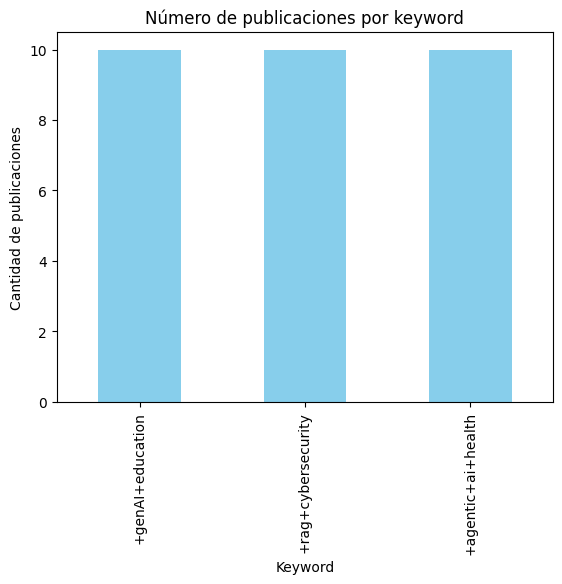

In [8]:
import matplotlib.pyplot as plt

# Distribución de publicaciones por keyword
r_keywords['keyword'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Número de publicaciones por keyword")
plt.xlabel("Keyword")
plt.ylabel("Cantidad de publicaciones")
plt.show()

c.2 Exploración gráfica de variables numéricas

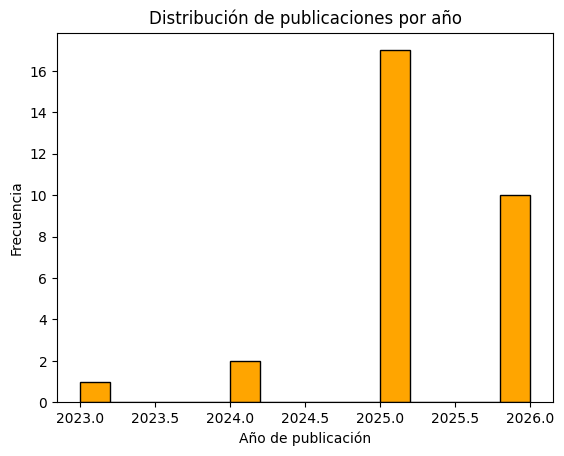

In [9]:
# Histograma de años de publicación
r_keywords['year'].dropna().plot(kind='hist', bins=15, color='orange', edgecolor='black')
plt.title("Distribución de publicaciones por año")
plt.xlabel("Año de publicación")
plt.ylabel("Frecuencia")
plt.show()


### 1.2: Extracción de datos de las entidades tipo author

<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio C: (3 ptos.) </b>

<b>Objetivo:</b> Obtener metadatos de entidades tipo *author* y almacenar resultados en un dataframe.

<b>Requisito:</b> El dataframe deberá llamarse <i>r_authors</i>.

<b>Salida esperada:</b> Presentar al menos 5 filas aleatorias del dataframe creado.

</div>

<b> a. Preparar el request (importar libraries y definir parámetros generales para usar la API works) e implementar una función para realizar la llamada en función del parámetro enviado.</b>

Luego de la revisión de la documentación, crear una función para obtener información de las entidades de tipo *author*, que reciba como parámetro el valor leído desde el archivo proporcionado.

In [10]:
###########################
# SOLUCIÓN: Definir función que reciba parámetros (nombre de autores) para realizar la búsqueda.
###########################

# Endpoint base de Crossref para publicaciones
endpoint = "https://api.crossref.org/v1/works"

def buscar_autor(author, rows=5):
    """
    Función que consulta la API de Crossref para un autor dado.
    Retorna una lista de diccionarios con metadatos de publicaciones.
    """
    params = {"query.author": author, "rows": rows}
    response = requests.get(endpoint, params=params)

    if response.status_code == 200:
        data = response.json()
        resultados = []
        for item in data['message']['items']:
            resultados.append({
                "author_query": author,
                "title": item.get('title', ['No disponible'])[0],
                "DOI": item.get('DOI', 'No disponible'),
                "authors": [a.get('family') for a in item.get('author', [])],
                "year": item.get('issued', {}).get('date-parts', [[None]])[0][0]
            })
        return resultados
    else:
        print("Error en la consulta:", response.status_code)
        return []




###########################
# SOLUCIÓN: Llamar a la función creada con cada valor de author para
# extraer sus metadatos
###########################

# Filtrar solo autores del DataFrame original
authors = kwDF[kwDF['type'] == 'author']['name_preprocesado'].tolist()

# Lista para almacenar resultados
resultados_authors = []

for au in authors:
    resultados_au = buscar_autor(au, rows=5)
    resultados_authors.extend(resultados_au)
    time.sleep(1)  # pequeña pausa para no saturar la API

# Convertir a DataFrame
r_authors = pd.DataFrame(resultados_authors)


print("Cantidad de publicaciones recuperadas:", r_authors.shape[0])
r_authors.sample(5)




Cantidad de publicaciones recuperadas: 15


,author_query,title,DOI,authors,year
1,+Yael+Feldman-Maggor,Identifying self-regulated learning in chemist...,10.1515/cti-2022-0036,[Feldman-Maggor],2023
6,+Suhail+Ahmad+Rana,Exploring the Role of Retrieval-Augmented Gene...,10.2139/ssrn.5357871,[Ahmad Rana],2025
2,+Yael+Feldman-Maggor,AI for chemistry teaching: responsible AI and ...,10.1515/cti-2024-0014,"[Blonder, Feldman-Maggor]",2024
13,+Tania+Gentic,Auditory Culture in Early Twentieth-Century Spain,10.4324/9780367810207-47,[Gentic],2025
8,+Suhail+Ahmad+Rana,AI Governance in Smart Grids and Industrial Au...,10.2139/ssrn.5509958,[Ahmad Rana],2025


<b> b. Procesar los datos extraídos y almacenarlos en un dataframe.</b>


In [11]:
###########################
# SOLUCIÓN: Procesar el json devuelto y almacenar resultados en un dataframe
###########################


# Lista para acumular resultados de autores
resultados_authors = []

# Iterar sobre cada autor preprocesado
for au in authors:
    data = buscar_autor(au, rows=10)   # pedimos hasta 10 resultados por autor
    resultados_authors.extend(data)    # agregamos a la lista
    time.sleep(1)                      # pausa para no saturar la API

# Convertir lista de diccionarios a DataFrame
r_authors = pd.DataFrame(resultados_authors)


In [12]:
###########################
# SOLUCIÓN: Presentar/imprimir al menos 5 filas aleatorias de los datos extraídos.
###########################


print("Cantidad de publicaciones recuperadas:", r_authors.shape[0])
r_authors.sample(5)


Cantidad de publicaciones recuperadas: 30


,author_query,title,DOI,authors,year
27,+Tania+Gentic,Beyond the Visual City: The Sound of Space in ...,10.1353/hir.2014.0019,[Gentic],2014
1,+Yael+Feldman-Maggor,Identifying self-regulated learning in chemist...,10.1515/cti-2022-0036,[Feldman-Maggor],2023
26,+Tania+Gentic,Translocal Misreadings: Eugeni d’Ors in Latin ...,10.1007/978-3-319-58208-5_10,[Gentic],2017
19,+Suhail+Ahmad+Rana,Myocardial protection with Glucose-Insulin-Pot...,10.12669/pjms.332.12414,"[Ahmad, Altaf Ahmad, Ahsan Qureshi, Ahmad Raza...",2017
2,+Yael+Feldman-Maggor,AI for chemistry teaching: responsible AI and ...,10.1515/cti-2024-0014,"[Blonder, Feldman-Maggor]",2024


<b> c. Exploración del dataset.</b>

Aplicar resúmenes de datos sobre el dataset creado. Elegir las mejores técnicas univariantes (estadísticas y gráficas), dependiendo del tipo de variable.

In [13]:
###########################
# SOLUCIÓN: Resultados de la exploración
###########################

# Información general del DataFrame
print(r_authors.info())

# Estadísticas descriptivas de la variable numérica (año de publicación)
print(r_authors['year'].describe())

# Conteo de publicaciones por autor consultado
print(r_authors['author_query'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   author_query  30 non-null     object
 1   title         30 non-null     object
 2   DOI           30 non-null     object
 3   authors       30 non-null     object
 4   year          30 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.3+ KB
None
count      30.000000
mean     2021.166667
std         5.226480
min      2009.000000
25%      2017.000000
50%      2024.000000
75%      2025.000000
max      2026.000000
Name: year, dtype: float64
author_query
+Yael+Feldman-Maggor    10
+Suhail+Ahmad+Rana      10
+Tania+Gentic           10
Name: count, dtype: int64


c.1 Exploración gráfica de variables categóricas

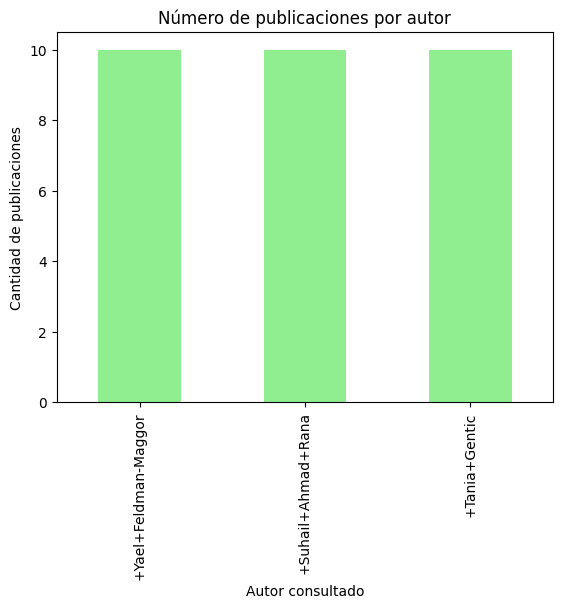

In [14]:
# Distribución de publicaciones por autor
r_authors['author_query'].value_counts().plot(kind='bar', color='lightgreen')
plt.title("Número de publicaciones por autor")
plt.xlabel("Autor consultado")
plt.ylabel("Cantidad de publicaciones")
plt.show()

C.2 Exploración gráfica de variables numéricas

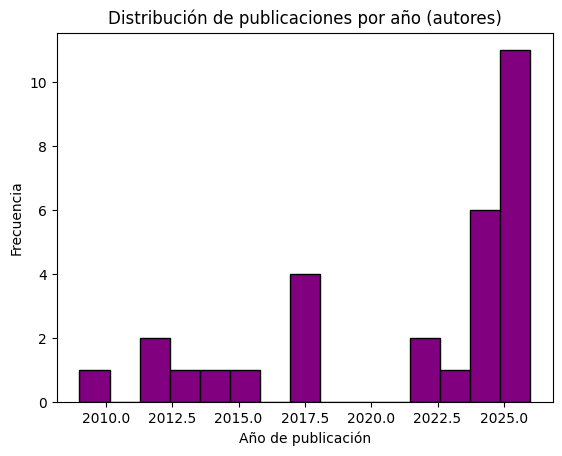

In [15]:
# Histograma de años de publicación
r_authors['year'].dropna().plot(kind='hist', bins=15, color='purple', edgecolor='black')
plt.title("Distribución de publicaciones por año (autores)")
plt.xlabel("Año de publicación")
plt.ylabel("Frecuencia")
plt.show()


## Fase 2: Integración de datos

<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio D (3 ptos): Integración de datos obtenidos (tanto de keywords, como de authors) </b>

<b>Objetivo:</b> Crear un dataframe único donde consten los datos obtenidos con cada tipo de entidad.

<b>Requisitos:</b>

- A partir de la estructuras de datos <i> r_keywords </i> y <i> r_authors </i>, determinar cuáles de los atributos son comunes y cuáles son diferentes para crear una sola estructura tipo dataframe que almacene todos los datos extraídos.

<b>Salida esperada:</b> Presentar/imprimir un <i>sample</i> de 10 elementos que consten en el dataframe único.


</div>

Resultado

Identificar atributos comunes y diferentes
Comunes:

1.- title (título de la publicación)

2.- DOI (identificador digital)

3.- authors (lista de autores)

4.- year (año de publicación)

Diferentes:

1.- keyword (consulta por palabra clave)

2.- author_query (consulta por autor)

Para integrarlos, podemos crear una columna genérica llamada query y otra llamada type que indique si la consulta fue por keyword o author.

In [16]:
######################
# SOLUCIÓN  Integración de datos en un único dataframe
######################


# Normalizar columnas de r_keywords
df_keywords = r_keywords.copy()
df_keywords['type'] = 'keyword'
df_keywords['query'] = df_keywords['keyword']
df_keywords = df_keywords[['type', 'query', 'title', 'DOI', 'authors', 'year']]

# Normalizar columnas de r_authors
df_authors = r_authors.copy()
df_authors['type'] = 'author'
df_authors['query'] = df_authors['author_query']
df_authors = df_authors[['type', 'query', 'title', 'DOI', 'authors', 'year']]

# Concatenar ambos DataFrames
df_integrado = pd.concat([df_keywords, df_authors], ignore_index=True)

###########################
# SOLUCIÓN: Presentar/imprimir un sample de 10 elementos
###########################

print("Cantidad total de registros integrados:", df_integrado.shape[0])
df_integrado.sample(10)



Cantidad total de registros integrados: 60


,type,query,title,DOI,authors,year
10,keyword,+rag+cybersecurity,Automating Threat Intelligence Analysis with R...,10.21275/sr24502103758,[Pal Singh Shobhit],2024
51,author,+Tania+Gentic,La excentricidad del texto: El carácter poétic...,10.1353/rvs.2012.0072,[Gentic],2012
0,keyword,+genAI+education,Beware of Genai Pitfalls in Education: The Eff...,10.2139/ssrn.4954002,"[Yang, Zhang]",2024
48,author,+Suhail+Ahmad+Rana,THE EFFECTS OF SENTENCE WRITING AS SEMANTIC EL...,10.56924/tasnim.s1.2025/29,[Suhail],2025
42,author,+Suhail+Ahmad+Rana,Operationalizing AI Governance in Bulk Electri...,10.2139/ssrn.6711358,[Ahmad Rana],2026
18,keyword,+rag+cybersecurity,YOLOv12-RAG-Qwen Hybrid Framework for Classroo...,10.1109/isaics66888.2025.11350093,"[Huang, Ji, Liang, Gao, Li, Rong]",2025
34,author,+Yael+Feldman-Maggor,Efficiency vs. effectiveness,10.20851/ll.v8.60,"[Viberg, Feldman Maggor, Wong]",2026
31,author,+Yael+Feldman-Maggor,Identifying self-regulated learning in chemist...,10.1515/cti-2022-0036,[Feldman-Maggor],2023
50,author,+Tania+Gentic,"Journalism, Media, Mass Culture",10.1017/9781108891226.025,[Gentic],2022
27,keyword,+agentic+ai+health,Agentic AI Opportunities,10.4018/979-8-3373-1877-6.ch008,[],2025


# Uso de la IA

En el desarrollo de esta actividad se utilizo herramientas de inteligencia artificial generativa como apoyo en la elaboración de código y explicaciones, con un porcentaje del 70%.

### Exportar resultados a formato HTML

In [ ]:
!jupyter nbconvert --pdf Lab1_API.ipynb